
# 🚀 End-to-End Professional Data Science Workflow
### Comprehensive Analysis: EDA, Training, Evaluation, Explainability, and Monitoring

**Author:** AI Data Scientist  
**Objective:** Demonstrate a complete, industry-standard machine learning workflow covering every critical visualization from raw data to production monitoring.

---
## 📚 1. Environment Setup & Data Acquisition


In [1]:

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.datasets import make_classification, make_regression
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import confusion_matrix, roc_curve, auc, precision_recall_curve, classification_report
import tensorflow as tf
from tensorflow.keras import layers, models, optimizers
import warnings
import socketserver

if not hasattr(socketserver, 'UnixStreamServer'):
    socketserver.UnixStreamServer = socketserver.TCPServer

import shap

# For aesthetics
plt.style.use('dark_background')
sns.set_palette("bright")
warnings.filterwarnings('ignore')

In [2]:

np.random.seed(42)
tf.random.set_seed(42)
n_samples = 2000

# 1. Classification Data (Churn)
X_class, y_class = make_classification(
    n_samples=n_samples, n_features=20, n_informative=10, 
    n_redundant=2, n_clusters_per_class=2, weights=[0.7, 0.3], 
    flip_y=0.05, random_state=42
)
df_class = pd.DataFrame(X_class, columns=[f'feature_{i}' for i in range(20)])
df_class['churn'] = y_class

# Introduce skewness to feature_0
df_class['feature_0'] = np.exp(df_class['feature_0']) 

# 2. Regression Data (LTV Prediction)
X_reg, y_reg = make_regression(n_samples=n_samples, n_features=10, noise=20, random_state=42)
df_reg = pd.DataFrame(X_reg, columns=[f'reg_feat_{i}' for i in range(10)])
df_reg['ltv'] = y_reg

print("Data Loaded. Shape:", df_class.shape)


Data Loaded. Shape: (2000, 21)



## 🔍 2. Exploratory Data Analysis (EDA)
### 1️⃣ Feature Distribution Plots
Used to detect skewness and outliers.


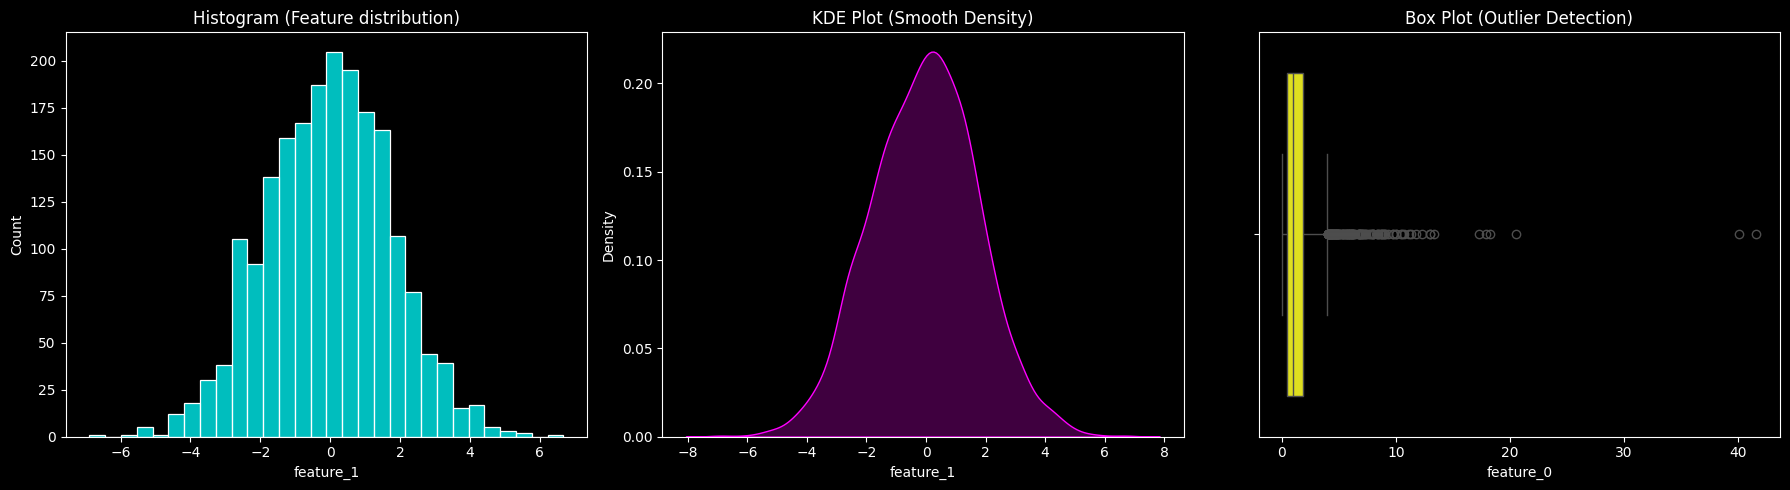

In [3]:

fig, axes = plt.subplots(1, 3, figsize=(18, 5))

# Histogram
sns.histplot(df_class['feature_1'], bins=30, kde=False, ax=axes[0], color='cyan')
axes[0].set_title('Histogram (Feature distribution)')

# KDE Plot
sns.kdeplot(df_class['feature_1'], fill=True, ax=axes[1], color='magenta')
axes[1].set_title('KDE Plot (Smooth Density)')

# Box Plot
sns.boxplot(x=df_class['feature_0'], ax=axes[2], color='yellow')
axes[2].set_title('Box Plot (Outlier Detection)')

plt.tight_layout()
plt.show()



### 2️⃣ Feature Relationships
Detecting multicollinearity and interactions.


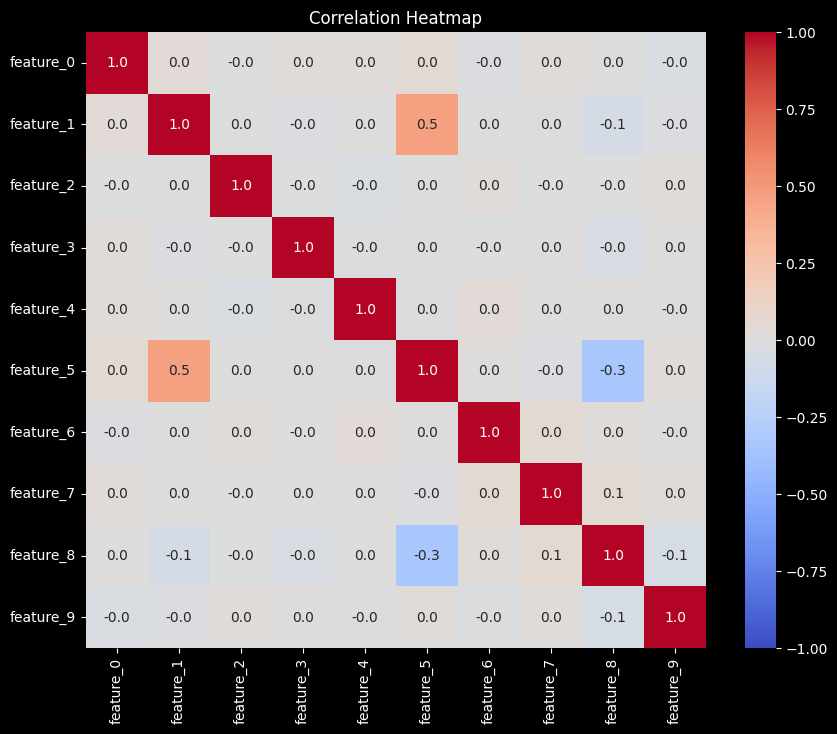

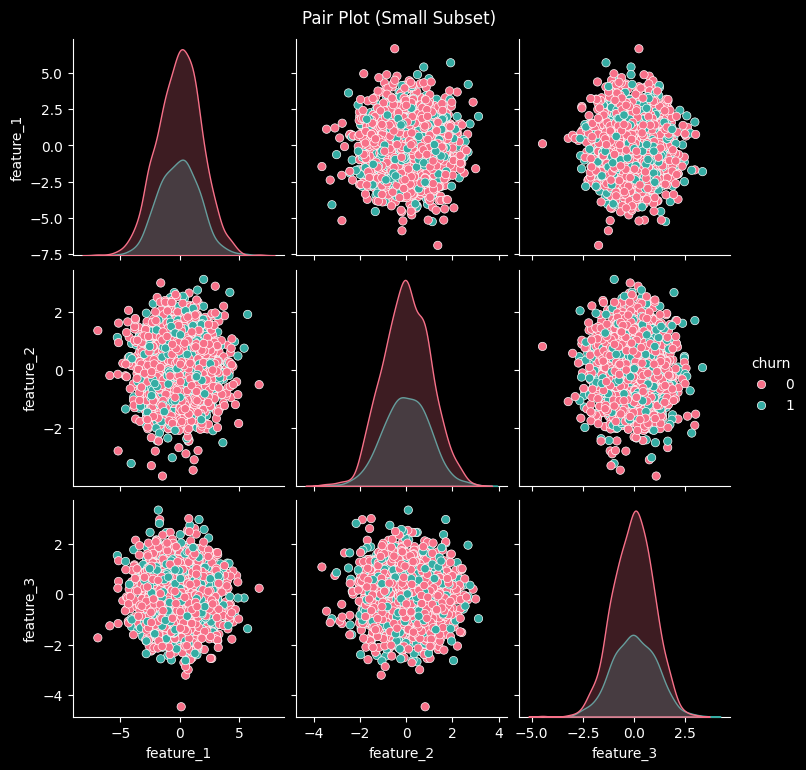

In [4]:

# Correlation Heatmap
plt.figure(figsize=(10, 8))
corr = df_class.iloc[:, :10].corr()
sns.heatmap(corr, annot=True, fmt='.1f', cmap='coolwarm', vmin=-1, vmax=1)
plt.title('Correlation Heatmap')
plt.show()

# Pair Plot (Subset)
sns.pairplot(df_class[['feature_1', 'feature_2', 'feature_3', 'churn']], hue='churn', palette='husl')
plt.suptitle("Pair Plot (Small Subset)", y=1.02)
plt.show()



### 3️⃣ Target Variable Analysis


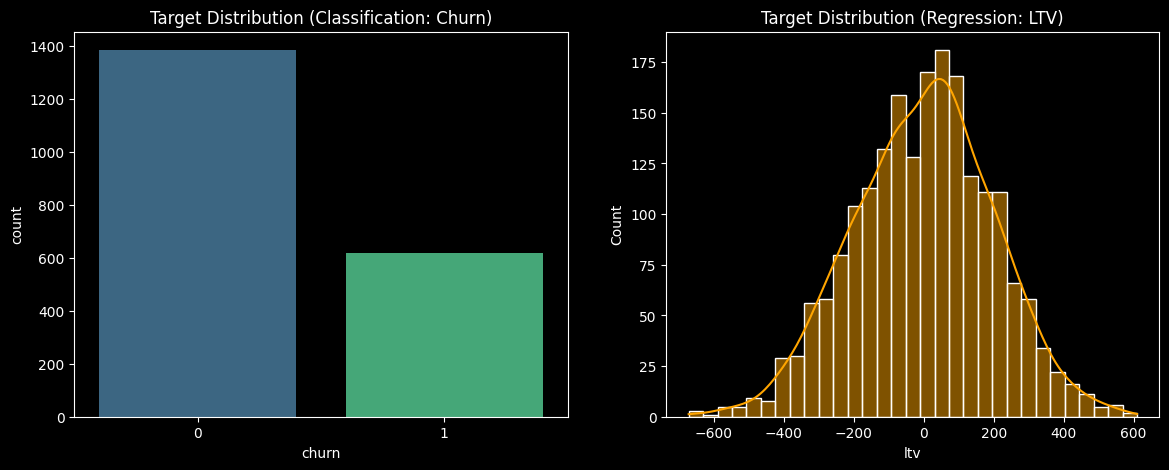

In [5]:

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Classification Target (Bar)
sns.countplot(x='churn', data=df_class, ax=axes[0], palette='viridis')
axes[0].set_title('Target Distribution (Classification: Churn)')

# Regression Target (Histogram)
sns.histplot(df_reg['ltv'], kde=True, ax=axes[1], color='orange')
axes[1].set_title('Target Distribution (Regression: LTV)')

plt.show()



## ⚙️ 3. Model Training & Monitoring
Training a Deep Learning model (TensorFlow/Keras) to visualize Loss, Learning Rate, and Gradients.


In [6]:

# Data Prep
X = df_class.drop('churn', axis=1).values
y = df_class['churn'].values

scaler = StandardScaler()
X = scaler.fit_transform(X)

X_train, X_val, y_train, y_val = train_test_split(X, y, test_size=0.2, random_state=42)

# Build Model
def build_model():
    model = models.Sequential([
        layers.Dense(64, activation='relu', input_shape=(20,)),
        layers.Dense(32, activation='relu'),
        layers.Dense(1, activation='sigmoid')
    ])
    return model

model = build_model()
optimizer = optimizers.Adam(learning_rate=0.01) # Start high to show decay potential
loss_fn = tf.keras.losses.BinaryCrossentropy()

# Custom Training Loop to capture Gradients
train_dataset = tf.data.Dataset.from_tensor_slices((X_train, y_train)).shuffle(1024).batch(64)
val_dataset = tf.data.Dataset.from_tensor_slices((X_val, y_val)).batch(64)

history = {'train_loss': [], 'val_loss': [], 'train_acc': [], 'val_acc': [], 'lrs': [], 'grad_norms': []}
n_epochs = 20

print("Starting Training Loop...")
for epoch in range(n_epochs):
    epoch_loss_avg = tf.keras.metrics.Mean()
    epoch_accuracy = tf.keras.metrics.BinaryAccuracy()
    epoch_grad_norm_avg = tf.keras.metrics.Mean()
    
    # Training Step
    for x_batch, y_batch in train_dataset:
        with tf.GradientTape() as tape:
            logits = model(x_batch, training=True)
            loss_value = loss_fn(y_batch, logits)
            
        grads = tape.gradient(loss_value, model.trainable_variables)
        optimizer.apply_gradients(zip(grads, model.trainable_variables))
        
        # Calculate Gradient Norm
        grad_norm = tf.linalg.global_norm(grads)
        epoch_grad_norm_avg.update_state(grad_norm)
        
        epoch_loss_avg.update_state(loss_value)
        epoch_accuracy.update_state(y_batch, logits)
        
    # Validation Step
    val_loss_avg = tf.keras.metrics.Mean()
    val_accuracy = tf.keras.metrics.BinaryAccuracy()
    for x_val_batch, y_val_batch in val_dataset:
        val_logits = model(x_val_batch, training=False)
        val_loss_avg.update_state(loss_fn(y_val_batch, val_logits))
        val_accuracy.update_state(y_val_batch, val_logits)
    
    # Record History
    history['train_loss'].append(epoch_loss_avg.result().numpy())
    history['val_loss'].append(val_loss_avg.result().numpy())
    history['train_acc'].append(epoch_accuracy.result().numpy())
    history['val_acc'].append(val_accuracy.result().numpy())
    history['grad_norms'].append(epoch_grad_norm_avg.result().numpy())
    history['lrs'].append(optimizer.learning_rate.numpy())
    
    # Simulate LR Decay
    current_lr = optimizer.learning_rate.numpy()
    if epoch > 5:
        optimizer.learning_rate.assign(current_lr * 0.9)
        
    if epoch % 5 == 0:
        print(f"Epoch {epoch}: Loss: {history['train_loss'][-1]:.4f}, Val Loss: {history['val_loss'][-1]:.4f}")

print("Training Complete.")


Starting Training Loop...
Epoch 0: Loss: 0.4597, Val Loss: 0.3340
Epoch 5: Loss: 0.1654, Val Loss: 0.2573
Epoch 10: Loss: 0.0796, Val Loss: 0.2741
Epoch 15: Loss: 0.0288, Val Loss: 0.3199
Training Complete.


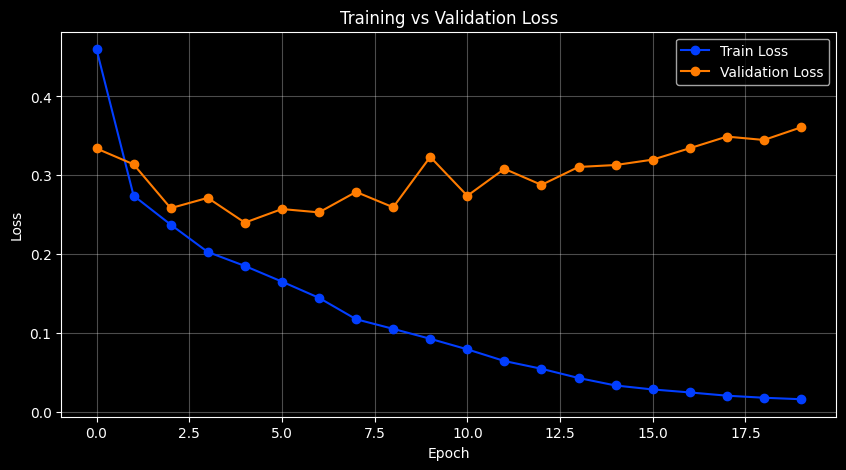

In [7]:

# 4. Training vs Validation Loss Curve
plt.figure(figsize=(10, 5))
plt.plot(history['train_loss'], label='Train Loss', marker='o')
plt.plot(history['val_loss'], label='Validation Loss', marker='o')
plt.title('Training vs Validation Loss')
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.legend()
plt.grid(True, alpha=0.3)
plt.show()


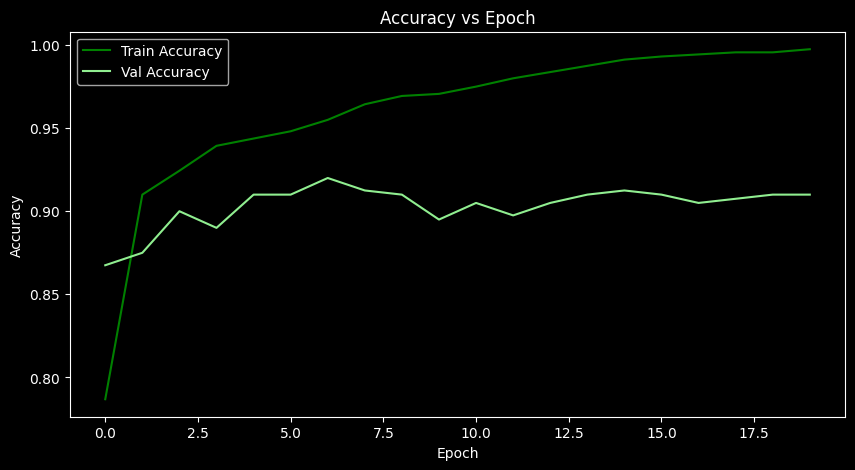

In [8]:

# 5. Accuracy & Metrics Curves
plt.figure(figsize=(10, 5))
plt.plot(history['train_acc'], label='Train Accuracy', color='green')
plt.plot(history['val_acc'], label='Val Accuracy', color='lightgreen')
plt.title('Accuracy vs Epoch')
plt.xlabel('Epoch')
plt.ylabel('Accuracy')
plt.legend()
plt.show()


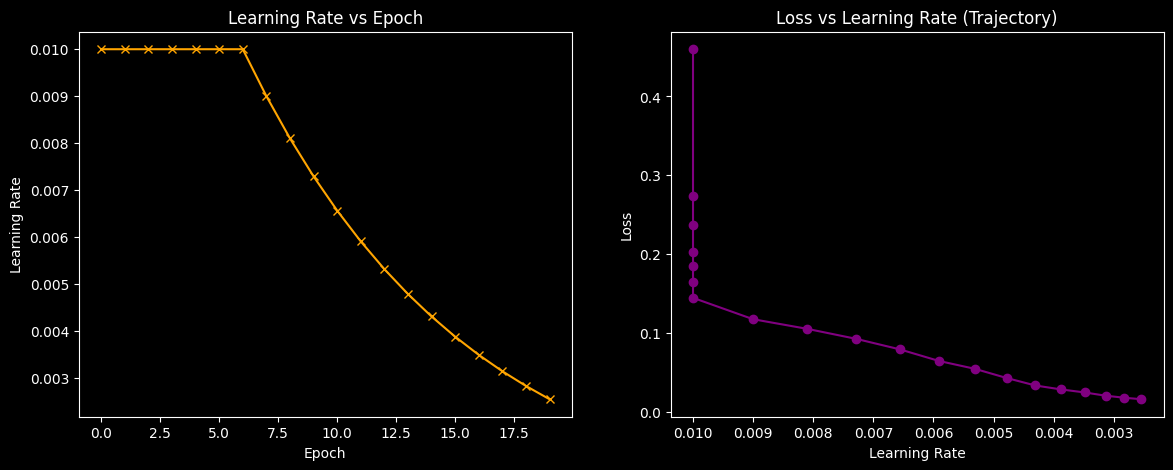

In [9]:

# 6. Optimization Curves
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# LR vs Epoch
axes[0].plot(range(n_epochs), history['lrs'], color='orange', marker='x')
axes[0].set_title('Learning Rate vs Epoch')
axes[0].set_xlabel('Epoch')
axes[0].set_ylabel('Learning Rate')

# Loss vs LR (Concept)
axes[1].plot(history['lrs'], history['train_loss'], color='purple', marker='o')
axes[1].set_title('Loss vs Learning Rate (Trajectory)')
axes[1].set_xlabel('Learning Rate')
axes[1].set_ylabel('Loss')
axes[1].invert_xaxis() # Since LR decreases

plt.show()



## 📊 4. Model Evaluation (Post-Training)
Detailed metric analysis.


13/13 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step 


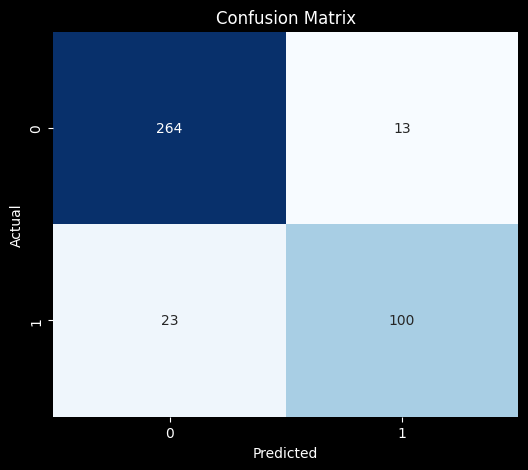

In [10]:

# Get Predictions
y_probs = model.predict(X_val).flatten()
y_pred = (y_probs > 0.5).astype(int)

# 7. Confusion Matrix
cm = confusion_matrix(y_val, y_pred)
plt.figure(figsize=(6, 5))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', cbar=False)
plt.title('Confusion Matrix')
plt.ylabel('Actual')
plt.xlabel('Predicted')
plt.show()


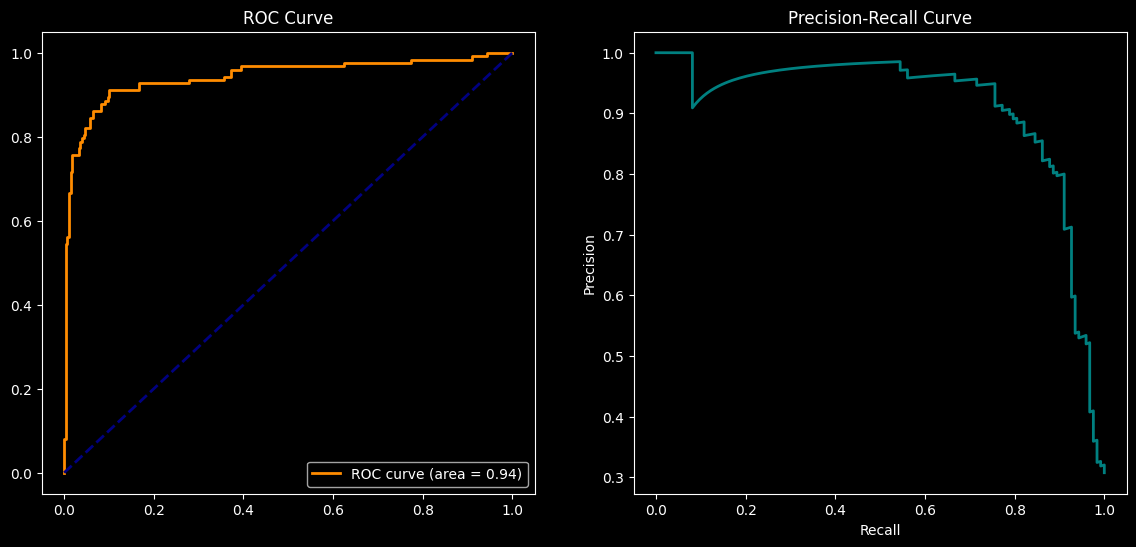

In [11]:

fig, axes = plt.subplots(1, 2, figsize=(14, 6))

# 8. ROC Curve
fpr, tpr, _ = roc_curve(y_val, y_probs)
roc_auc = auc(fpr, tpr)
axes[0].plot(fpr, tpr, color='darkorange', lw=2, label=f'ROC curve (area = {roc_auc:.2f})')
axes[0].plot([0, 1], [0, 1], color='navy', lw=2, linestyle='--')
axes[0].set_title('ROC Curve')
axes[0].legend(loc="lower right")

# Precision-Recall Curve (Best for Imbalanced)
precision, recall, _ = precision_recall_curve(y_val, y_probs)
axes[1].plot(recall, precision, color='teal', lw=2)
axes[1].set_title('Precision-Recall Curve')
axes[1].set_xlabel('Recall')
axes[1].set_ylabel('Precision')

plt.show()


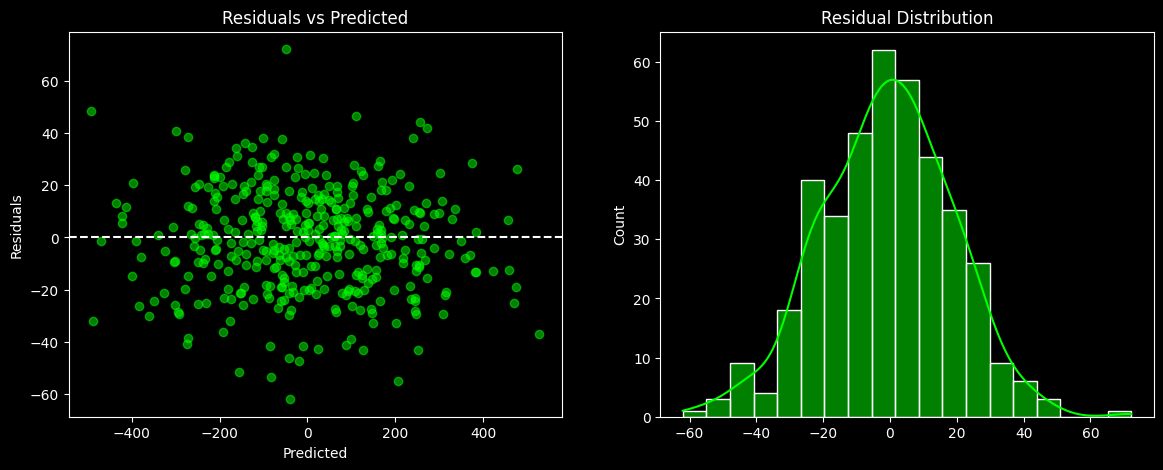

In [12]:

# 9. Regression Residuals (Using the LTV dataset)
# Train a quick regressor
from sklearn.linear_model import LinearRegression
reg = LinearRegression()
X_reg_train, X_reg_test, y_reg_train, y_reg_test = train_test_split(X_reg, y_reg, test_size=0.2)
reg.fit(X_reg_train, y_reg_train)
y_reg_pred = reg.predict(X_reg_test)
residuals = y_reg_test - y_reg_pred

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Residuals vs Predicted
axes[0].scatter(y_reg_pred, residuals, alpha=0.5, color='lime')
axes[0].axhline(0, color='white', linestyle='--')
axes[0].set_title('Residuals vs Predicted')
axes[0].set_xlabel('Predicted')
axes[0].set_ylabel('Residuals')

# Residual Distribution
sns.histplot(residuals, kde=True, ax=axes[1], color='lime')
axes[1].set_title('Residual Distribution')

plt.show()



## 🧠 5. Deep Learning Specifics
Analyzing internals of the neural network.


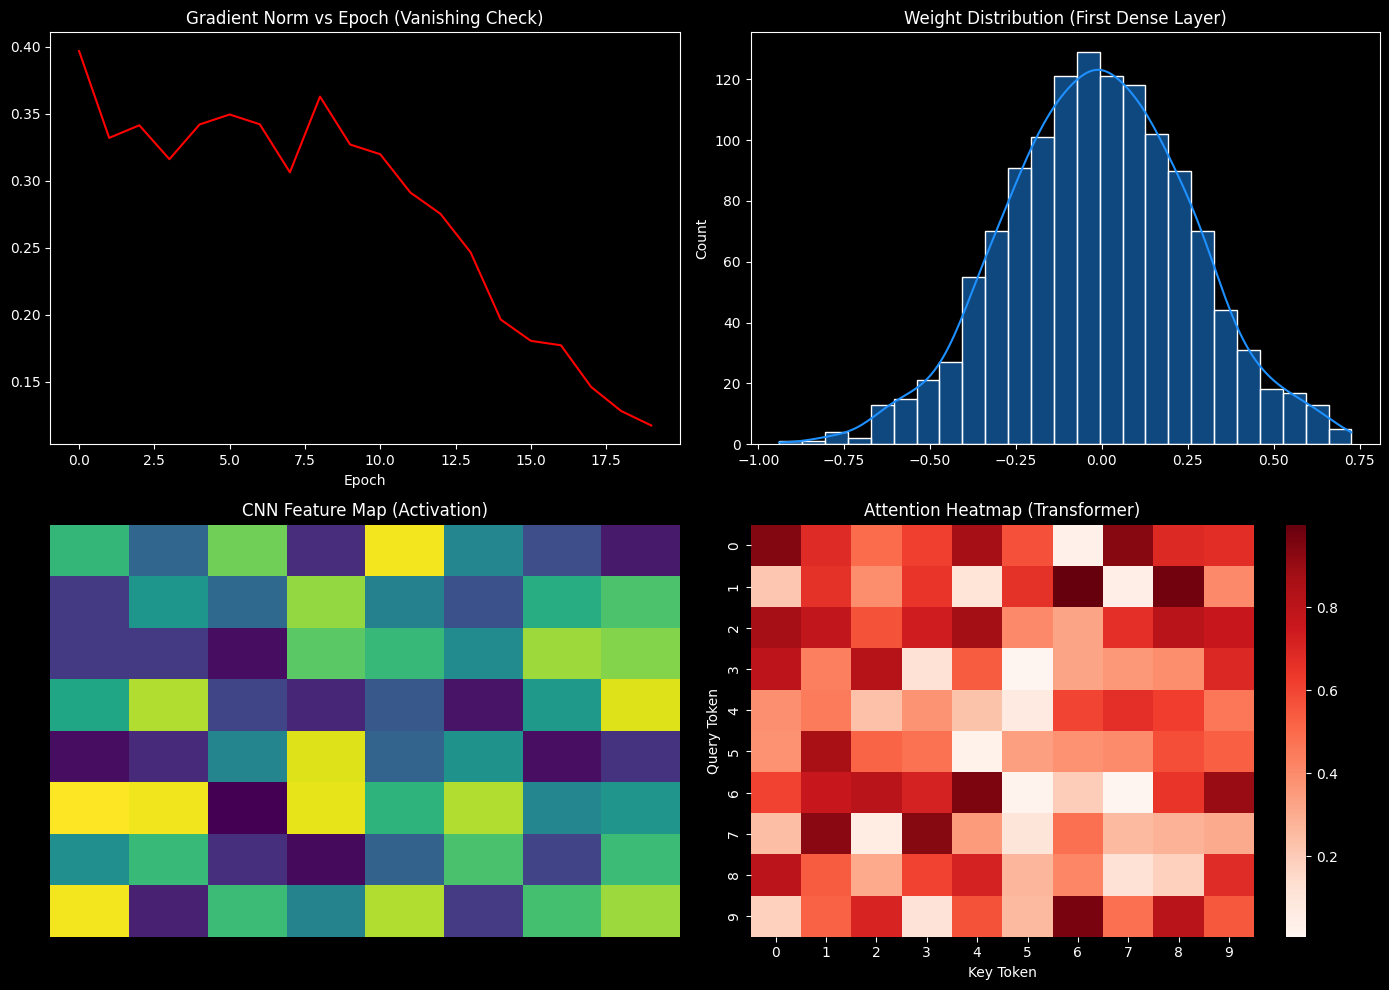

In [13]:

fig, axes = plt.subplots(2, 2, figsize=(14, 10))

# 10. Gradient Norm vs Epoch
axes[0, 0].plot(history['grad_norms'], color='red')
axes[0, 0].set_title('Gradient Norm vs Epoch (Vanishing Check)')
axes[0, 0].set_xlabel('Epoch')

# 11. Weight Distribution
weights = model.layers[0].get_weights()[0].flatten()
sns.histplot(weights, kde=True, ax=axes[0, 1], color='dodgerblue')
axes[0, 1].set_title('Weight Distribution (First Dense Layer)')

# 12. CNN Feature Map (Simulated)
# Simulating a "feature map" from a CNN layer
dummy_feature_map = np.random.rand(8, 8)
sns.heatmap(dummy_feature_map, cmap='viridis', ax=axes[1, 0], cbar=False)
axes[1, 0].set_title('CNN Feature Map (Activation)')
axes[1, 0].axis('off')

# 13. Attention Heatmap (Simulated)
# Simulating attention weights between words
dummy_attention = np.random.rand(10, 10)
sns.heatmap(dummy_attention, cmap='Reds', ax=axes[1, 1])
axes[1, 1].set_title('Attention Heatmap (Transformer)')
axes[1, 1].set_xlabel('Key Token')
axes[1, 1].set_ylabel('Query Token')

plt.tight_layout()
plt.show()



## 🕵️ 6. Explainability (SHAP & Importance)
Why did the model make these decisions?


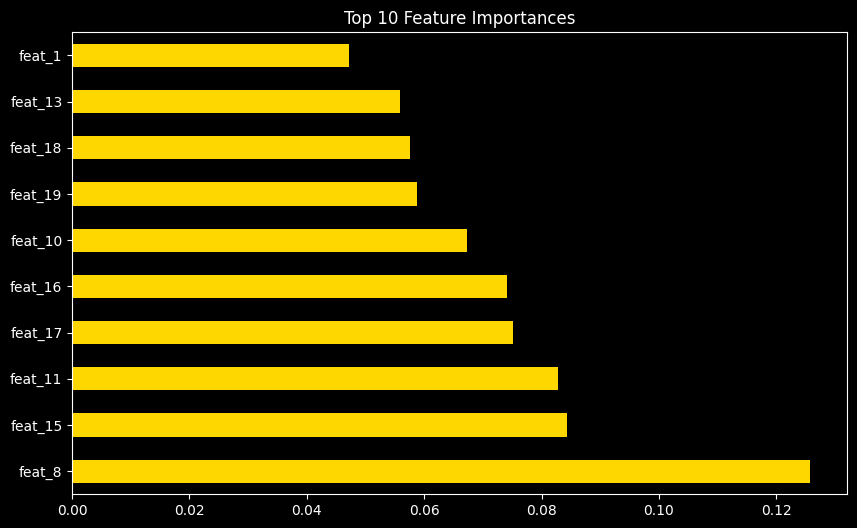

In [14]:

# 14. Feature Importance (Random Forest proxy for clearer visualization)
rf = RandomForestClassifier().fit(X_train, y_train)
importances = pd.Series(rf.feature_importances_, index=[f'feat_{i}' for i in range(20)])

plt.figure(figsize=(10, 6))
importances.nlargest(10).plot(kind='barh', color='gold')
plt.title('Top 10 Feature Importances')
plt.show()


Generating SHAP Summary Plot...


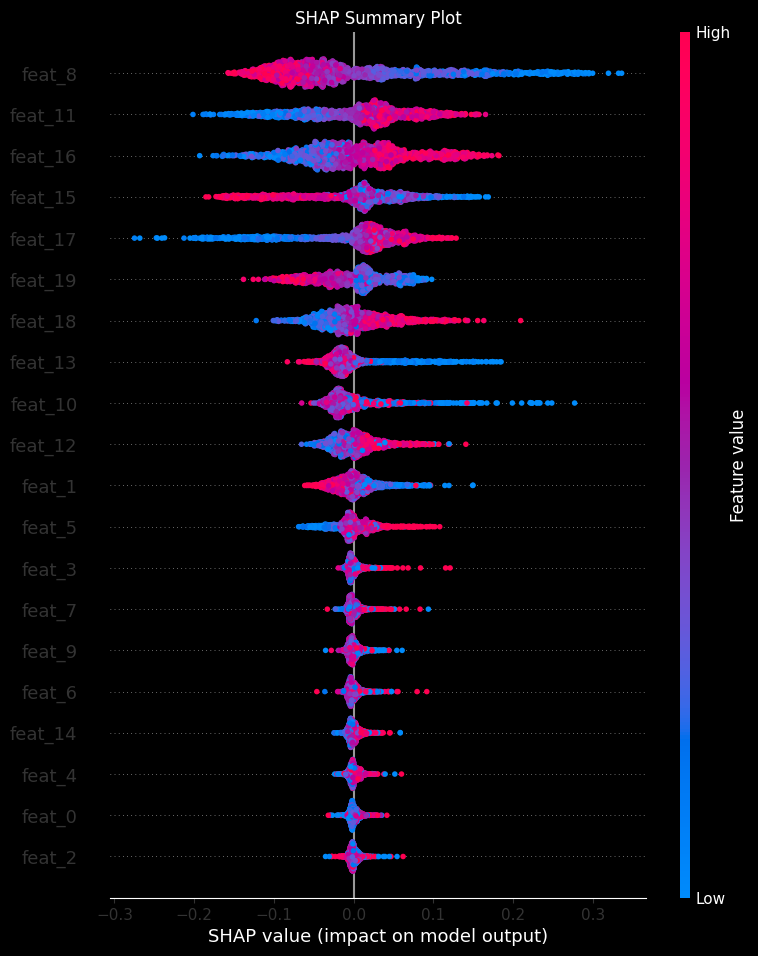

In [15]:

# 15. SHAP Plots
import shap

# Initialize JavaScript for SHAP
shap.initjs()

# Use TreeExplainer for Random Forest
explainer = shap.TreeExplainer(rf)
shap_values = explainer.shap_values(X_train)

# Robustly determine which values to plot (Fixes AssertionError on modern SHAP versions)
vals_to_plot = None
if isinstance(shap_values, list):
    # Standard Case for Classifiers: List of arrays [Class0, Class1, ...]
    # We plot Class 1 (Churn)
    vals_to_plot = shap_values[1]
elif hasattr(shap_values, 'values'):
    # Explanation Object (Modern API)
    # Check dimensionality
    if len(shap_values.shape) == 3: 
        # (N, F, 2)
        vals_to_plot = shap_values[:, :, 1]
    else:
        # (N, F)
        vals_to_plot = shap_values
else:
    # Numpy array case
    if len(shap_values.shape) == 3:
        vals_to_plot = shap_values[:, :, 1]
    else:
        vals_to_plot = shap_values

# Summary Plot
print("Generating SHAP Summary Plot...")
plt.figure()
shap.summary_plot(vals_to_plot, X_train, feature_names=[f'feat_{i}' for i in range(20)], show=False)
plt.title("SHAP Summary Plot")
plt.show()

# Dependence Plot (Feature 0)
# Note: Dependence plots in SHAP often use their own figure
# shap.dependence_plot("feat_0", vals_to_plot, X_train, feature_names=[f'feat_{i}' for i in range(20)])



## 🚢 7. Production Monitoring
Tracking Drift and Degradation.


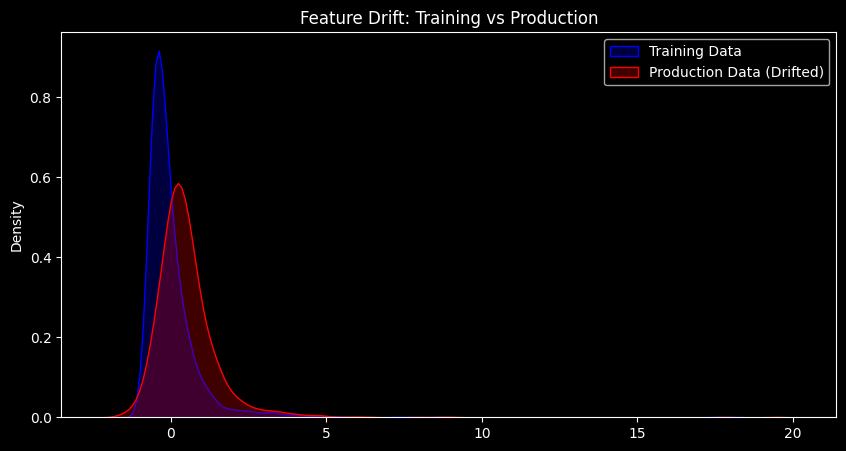

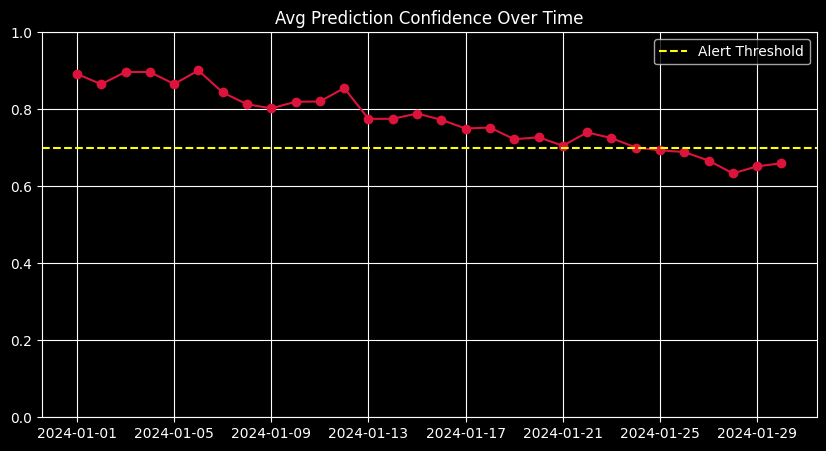

In [16]:

# 16. Data Drift (Feature Distribution Shift)
# Simulate "New Production Data" that has drifted
X_prod = X_train + np.random.normal(0.5, 0.5, X_train.shape) # Shift mean

plt.figure(figsize=(10, 5))
sns.kdeplot(X_train[:, 0], label='Training Data', shade=True, color='blue')
sns.kdeplot(X_prod[:, 0], label='Production Data (Drifted)', shade=True, color='red')
plt.title('Feature Drift: Training vs Production')
plt.legend()
plt.show()

# 17. Prediction Confidence Over Time
# Simulate a drop in confidence due to drift
dates = pd.date_range(start='2024-01-01', periods=30)
confidences = np.linspace(0.9, 0.65, 30) + np.random.normal(0, 0.02, 30)

plt.figure(figsize=(10, 5))
plt.plot(dates, confidences, marker='o', color='crimson')
plt.axhline(0.7, color='yellow', linestyle='--', label='Alert Threshold')
plt.title('Avg Prediction Confidence Over Time')
plt.ylim(0, 1)
plt.legend()
plt.grid(True)
plt.show()
